# Bootstrap Summary Analysis

This notebook reads archived bootstrap summary JSON files from `results/bootstrap_summaries/`, recomputes stability metrics directly from the saved rankings, and redraws plots without refitting any model.

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy

In [2]:
BASE_DIR = Path.cwd()
if not (BASE_DIR / "results").exists():
    candidate = Path("Code/real_data_0423")
    if candidate.exists():
        BASE_DIR = candidate.resolve()

SUMMARY_DIR = BASE_DIR / "results" / "bootstrap_summaries"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

DATASET_ORDER = ["chatbot_arena", "mtbench", "ultrafeedback", "in_house"]
METHOD_ORDER = ["proposed", "zhou_github", "standard_btl"]
METHOD_LABELS = {
    "proposed": "Proposed",
    "zhou_github": "Zhou github",
    "standard_btl": "Standard BTL",
}

BOOTSTRAP_SAMPLES = 500
TOP_K_VALUES = [3, 5]
ORDERED_EXACT_MATCH = True

print("BASE_DIR:", BASE_DIR)
print("SUMMARY_DIR:", SUMMARY_DIR)

BASE_DIR: /home/jinhongd/projects/HJA-Ranking/experiments
SUMMARY_DIR: /home/jinhongd/projects/HJA-Ranking/experiments/results/bootstrap_summaries


## Load summaries

In [3]:
def load_summary(dataset_name, bootstrap_samples=BOOTSTRAP_SAMPLES):
    path = SUMMARY_DIR / f"bootstrap_summary_{dataset_name}_samples_{int(bootstrap_samples)}.json"
    with path.open("r", encoding="utf-8") as f:
        payload = json.load(f)
    return payload[dataset_name]


def load_all_summaries(bootstrap_samples=BOOTSTRAP_SAMPLES):
    summaries = {}
    for dataset_name in DATASET_ORDER:
        path = SUMMARY_DIR / f"bootstrap_summary_{dataset_name}_samples_{int(bootstrap_samples)}.json"
        if path.exists():
            summaries[dataset_name] = load_summary(dataset_name, bootstrap_samples)
    if not summaries:
        raise FileNotFoundError(f"No archived summaries found in {SUMMARY_DIR} for samples={bootstrap_samples}")
    return summaries


summaries = load_all_summaries(BOOTSTRAP_SAMPLES)
list(summaries.keys())

['chatbot_arena', 'mtbench', 'ultrafeedback', 'in_house']

## Metric helpers

In [4]:
def jaccard_score(items_a, items_b):
    set_a = set(items_a)
    set_b = set(items_b)
    union = set_a | set_b
    return len(set_a & set_b) / len(union) if union else 1.0


def pairwise_agreement(reference_ranking, current_ranking):
    ref_pos = {item: idx for idx, item in enumerate(reference_ranking)}
    cur_pos = {item: idx for idx, item in enumerate(current_ranking)}
    items = list(reference_ranking)
    total = 0
    agree = 0
    for i in range(len(items)):
        for j in range(i + 1, len(items)):
            total += 1
            agree += int((ref_pos[items[i]] < ref_pos[items[j]]) == (cur_pos[items[i]] < cur_pos[items[j]]))
    return agree / total if total > 0 else 1.0


def bootstrap_top_k_metrics(method_summary, top_k, ordered_exact_match=ORDERED_EXACT_MATCH):
    baseline_ranking = method_summary["baseline"]["ranking"]["ranking"]
    bootstrap_rankings = method_summary.get("bootstrap_rankings", [])
    top_k = max(1, min(int(top_k), len(baseline_ranking)))
    baseline_top_k = baseline_ranking[:top_k]
    baseline_top_k_set = set(baseline_top_k)
    item_names = list(baseline_ranking)
    top_k_hits = {item_name: 0 for item_name in item_names}
    exact_match_values = []
    jaccard_values = []
    pairwise_values = []

    for ranking_summary in bootstrap_rankings:
        ranking = ranking_summary["ranking"]
        current_top_k = ranking[:top_k]
        current_top_k_set = set(current_top_k)
        if ordered_exact_match:
            exact_match = int(current_top_k == baseline_top_k)
        else:
            exact_match = int(current_top_k_set == baseline_top_k_set)
        exact_match_values.append(exact_match)
        jaccard_values.append(jaccard_score(baseline_top_k, current_top_k))
        pairwise_values.append(pairwise_agreement(baseline_ranking, ranking))
        for item_name in current_top_k:
            top_k_hits[item_name] += 1

    num_rankings = len(bootstrap_rankings)
    if num_rankings == 0:
        return {
            "top_k": top_k,
            "baseline_top_k": baseline_top_k,
            "successful_samples": 0,
            "exact_match_rate": math.nan,
            "exact_match_sd": math.nan,
            "exact_match_se": math.nan,
            "mean_jaccard": math.nan,
            "jaccard_sd": math.nan,
            "jaccard_se": math.nan,
            "mean_pairwise_agreement": math.nan,
            "pairwise_agreement_sd": math.nan,
            "pairwise_agreement_se": math.nan,
            "top_k_frequency": {item_name: math.nan for item_name in item_names},
        }

    exact_match_values = np.asarray(exact_match_values, dtype=float)
    jaccard_values = np.asarray(jaccard_values, dtype=float)
    pairwise_values = np.asarray(pairwise_values, dtype=float)
    ddof = 1 if num_rankings > 1 else 0

    return {
        "top_k": top_k,
        "baseline_top_k": baseline_top_k,
        "successful_samples": num_rankings,
        "exact_match_rate": float(np.mean(exact_match_values)),
        "exact_match_sd": float(np.std(exact_match_values, ddof=ddof)),
        "exact_match_se": float(np.std(exact_match_values, ddof=ddof) / np.sqrt(num_rankings)),
        "mean_jaccard": float(np.mean(jaccard_values)),
        "jaccard_sd": float(np.std(jaccard_values, ddof=ddof)),
        "jaccard_se": float(np.std(jaccard_values, ddof=ddof) / np.sqrt(num_rankings)),
        "mean_pairwise_agreement": float(np.mean(pairwise_values)),
        "pairwise_agreement_sd": float(np.std(pairwise_values, ddof=ddof)),
        "pairwise_agreement_se": float(np.std(pairwise_values, ddof=ddof) / np.sqrt(num_rankings)),
        "top_k_frequency": {
            item_name: top_k_hits[item_name] / num_rankings for item_name in item_names
        },
    }


def rank_distribution(method_summary):
    baseline_ranking = method_summary["baseline"]["ranking"]["ranking"]
    item_names = list(baseline_ranking)
    all_rankings = method_summary.get("bootstrap_rankings", [])
    values = {item_name: [] for item_name in item_names}
    for ranking_summary in all_rankings:
        item_to_rank = ranking_summary["item_to_rank"]
        for item_name in item_names:
            values[item_name].append(int(item_to_rank[item_name]))

    out = {}
    for item_name in item_names:
        ranks = np.asarray(values[item_name], dtype=float)
        if ranks.size == 0:
            out[item_name] = {
                "mean_rank": math.nan,
                "median_rank": math.nan,
                "rank_p05": math.nan,
                "rank_p95": math.nan,
                "rank_sd": math.nan,
            }
        else:
            out[item_name] = {
                "mean_rank": float(np.mean(ranks)),
                "median_rank": float(np.median(ranks)),
                "rank_p05": float(np.quantile(ranks, 0.05)),
                "rank_p95": float(np.quantile(ranks, 0.95)),
                "rank_sd": float(np.std(ranks)),
            }
    return out

## Summary table

In [5]:
def build_metric_table(summaries, top_k, ordered_exact_match=ORDERED_EXACT_MATCH):
    rows = []
    for dataset_name, dataset_summary in summaries.items():
        for method_name in METHOD_ORDER:
            metrics = bootstrap_top_k_metrics(
                dataset_summary["methods"][method_name],
                top_k=top_k,
                ordered_exact_match=ordered_exact_match,
            )
            rows.append({
                "dataset": dataset_name,
                "method": method_name,
                "successful_samples": metrics["successful_samples"],
                "exact_match_rate": metrics["exact_match_rate"],
                "exact_match_se": metrics["exact_match_se"],
                "mean_jaccard": metrics["mean_jaccard"],
                "jaccard_se": metrics["jaccard_se"],
                "mean_pairwise_agreement": metrics["mean_pairwise_agreement"],
                "pairwise_agreement_se": metrics["pairwise_agreement_se"],
            })
    return pd.DataFrame(rows)


metric_table = build_metric_table(summaries, top_k=3)
metric_table

,dataset,method,successful_samples,exact_match_rate,exact_match_se,mean_jaccard,jaccard_se,mean_pairwise_agreement,pairwise_agreement_se
0,chatbot_arena,proposed,500,0.694000,0.020630,0.995000,0.002227,0.961063,0.000731
1,chatbot_arena,zhou_github,500,0.494000,0.022381,1.000000,0.000000,0.953032,0.000727
2,chatbot_arena,standard_btl,500,0.514000,0.022374,1.000000,0.000000,0.956958,0.000654
3,mtbench,proposed,500,0.996000,0.002826,1.000000,0.000000,0.991333,0.001004
4,mtbench,zhou_github,500,0.650000,0.021352,1.000000,0.000000,0.976667,0.001423
5,mtbench,standard_btl,500,0.616000,0.021772,1.000000,0.000000,0.974400,0.001451
6,ultrafeedback,proposed,492,0.768293,0.019041,0.958333,0.006237,0.936917,0.001477
7,ultrafeedback,zhou_github,500,0.604000,0.021894,0.984000,0.003939,0.965632,0.000696
8,ultrafeedback,standard_btl,500,0.600000,0.021931,0.982000,0.004170,0.967074,0.000654
9,in_house,proposed,500,0.316000,0.020812,0.718600,0.011275,0.972592,0.000250


## Plot cross-dataset summary bars

Error bars show the standard error across successful bootstrap samples for each dataset-method cell.

/home/jinhongd/projects/HJA-Ranking/experiments/results/bootstrap_topk_stability_top_3_samples_500_ordered_from_json.png


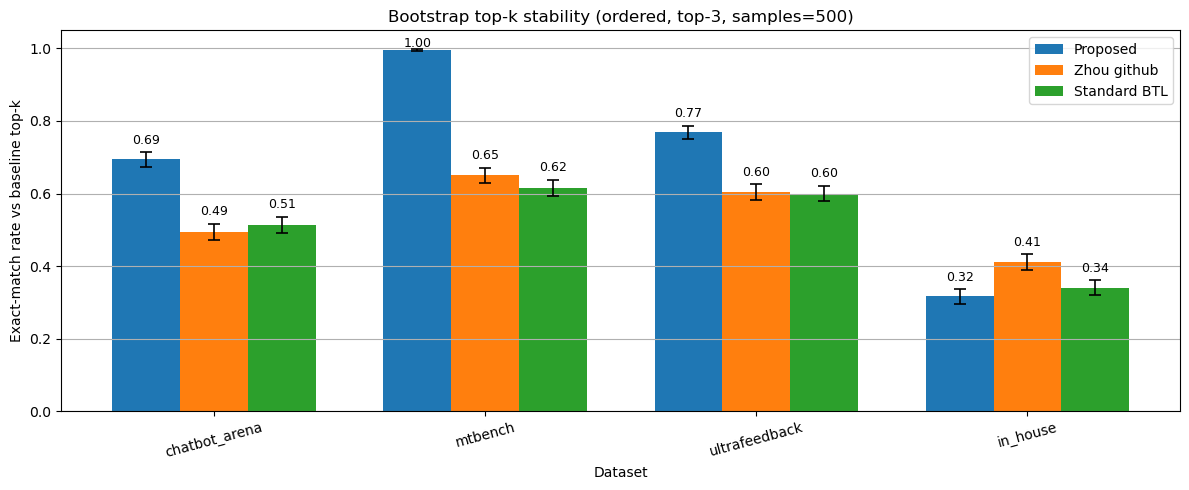

/home/jinhongd/projects/HJA-Ranking/experiments/results/bootstrap_topk_stability_top_5_samples_500_ordered_from_json.png


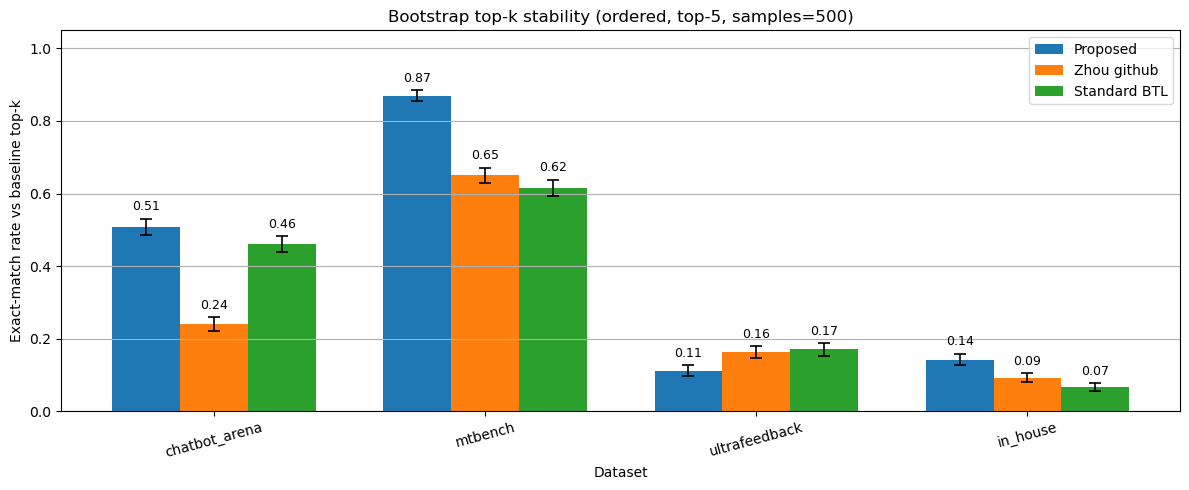

In [6]:
def plot_summary_bar(summaries, top_k, ordered_exact_match=ORDERED_EXACT_MATCH, annotate=True, save=True):
    dataset_names = [name for name in DATASET_ORDER if name in summaries]
    x = np.arange(len(dataset_names))
    width = 0.25

    fig, ax = plt.subplots(figsize=(12, 5))
    for offset, method_name in enumerate(METHOD_ORDER):
        values = []
        errors = []
        for dataset_name in dataset_names:
            method_summary = summaries[dataset_name]["methods"][method_name]
            metrics = bootstrap_top_k_metrics(
                method_summary,
                top_k=top_k,
                ordered_exact_match=ordered_exact_match,
            )
            values.append(metrics["exact_match_rate"])
            errors.append(metrics["exact_match_se"])

        bars = ax.bar(
            x + (offset - 1) * width,
            values,
            width=width,
            yerr=errors,
            capsize=4,
            error_kw={"elinewidth": 1.2, "capthick": 1.2},
            label=METHOD_LABELS[method_name],
        )
        if annotate:
            for bar, value, error in zip(bars, values, errors):
                if not math.isnan(value):
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        min(value + (0.0 if math.isnan(error) else error) + 0.015, 0.995),
                        f"{value:.2f}",
                        ha="center",
                        va="bottom",
                        fontsize=9,
                    )

    label = "ordered" if ordered_exact_match else "unordered"
    ax.set_xticks(x)
    ax.set_xticklabels(dataset_names, rotation=15)
    ax.set_ylabel("Exact-match rate vs baseline top-k")
    ax.set_xlabel("Dataset")
    ax.set_title(f"Bootstrap top-k stability ({label}, top-{int(top_k)}, samples={BOOTSTRAP_SAMPLES})")
    ax.set_ylim(0.0, 1.05)
    ax.grid(True, axis="y")
    ax.legend()
    fig.tight_layout()

    if save:
        output_path = RESULTS_DIR / f"bootstrap_topk_stability_top_{int(top_k)}_samples_{int(BOOTSTRAP_SAMPLES)}_{label}_from_json.png"
        fig.savefig(output_path, dpi=150)
        print(output_path)
    plt.show()


for top_k in TOP_K_VALUES:
    plot_summary_bar(summaries, top_k=top_k, ordered_exact_match=ORDERED_EXACT_MATCH)

## Per-dataset top-k inclusion table

In [7]:
DATASET_NAME = "mtbench"
TOP_K = 3
METHOD_NAME = "proposed"

method_summary = summaries[DATASET_NAME]["methods"][METHOD_NAME]
metrics = bootstrap_top_k_metrics(method_summary, top_k=TOP_K, ordered_exact_match=ORDERED_EXACT_MATCH)
top_k_table = pd.DataFrame(
    [
        {"item": item_name, "top_k_frequency": freq}
        for item_name, freq in metrics["top_k_frequency"].items()
    ]
).sort_values("top_k_frequency", ascending=False)
top_k_table

,item,top_k_frequency
0,claude-v1,1.0
1,gpt-4,1.0
2,gpt-3.5-turbo,1.0
3,alpaca-13b,0.0
4,vicuna-13b-v1.2,0.0
5,llama-13b,0.0


## Per-dataset rank distribution plot

/home/jinhongd/projects/HJA-Ranking/experiments/results/mtbench_proposed_rank_distribution_from_json.png


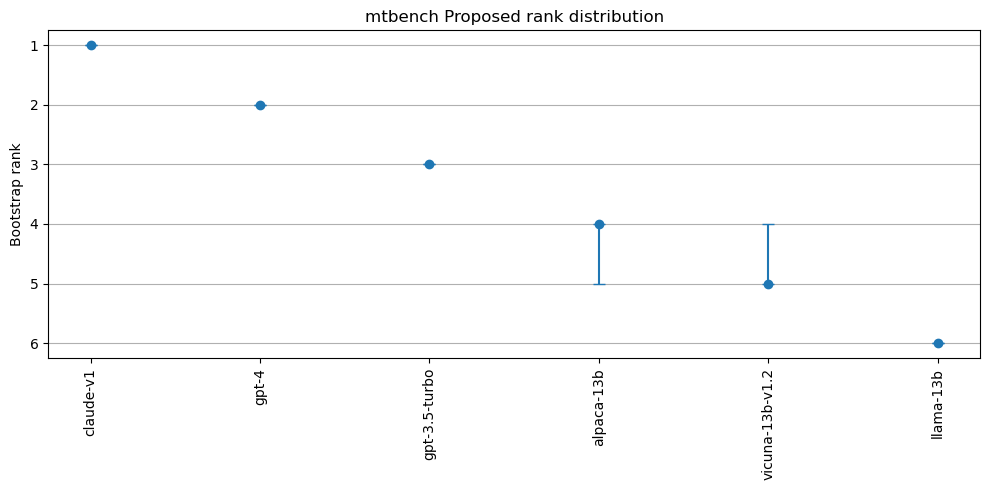

In [8]:
def plot_rank_distribution(dataset_name, method_name, save=True):
    method_summary = summaries[dataset_name]["methods"][method_name]
    distribution = rank_distribution(method_summary)
    item_names = list(distribution.keys())
    median_ranks = [distribution[item]["median_rank"] for item in item_names]
    low_err = [max(0.0, distribution[item]["median_rank"] - distribution[item]["rank_p05"]) for item in item_names]
    high_err = [max(0.0, distribution[item]["rank_p95"] - distribution[item]["median_rank"]) for item in item_names]

    fig, ax = plt.subplots(figsize=(max(10, 0.45 * len(item_names)), 5))
    x = np.arange(len(item_names))
    ax.errorbar(x, median_ranks, yerr=[low_err, high_err], fmt="o", capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(item_names, rotation=90)
    ax.set_ylabel("Bootstrap rank")
    ax.set_title(f"{dataset_name} {METHOD_LABELS[method_name]} rank distribution")
    ax.invert_yaxis()
    ax.grid(True, axis="y")
    fig.tight_layout()

    if save:
        output_path = RESULTS_DIR / f"{dataset_name}_{method_name}_rank_distribution_from_json.png"
        fig.savefig(output_path, dpi=150)
        print(output_path)
    plt.show()


plot_rank_distribution(DATASET_NAME, METHOD_NAME)

## Export a long-form metrics table

In [9]:
def export_metric_table(summaries, top_k_values=TOP_K_VALUES, ordered_exact_match=ORDERED_EXACT_MATCH):
    rows = []
    for top_k in top_k_values:
        for dataset_name, dataset_summary in summaries.items():
            for method_name in METHOD_ORDER:
                metrics = bootstrap_top_k_metrics(
                    dataset_summary["methods"][method_name],
                    top_k=top_k,
                    ordered_exact_match=ordered_exact_match,
                )
                rows.append({
                    "dataset": dataset_name,
                    "method": method_name,
                    "top_k": top_k,
                    "successful_samples": metrics["successful_samples"],
                    "exact_match_rate": metrics["exact_match_rate"],
                    "exact_match_sd": metrics["exact_match_sd"],
                    "exact_match_se": metrics["exact_match_se"],
                    "mean_jaccard": metrics["mean_jaccard"],
                    "jaccard_sd": metrics["jaccard_sd"],
                    "jaccard_se": metrics["jaccard_se"],
                    "mean_pairwise_agreement": metrics["mean_pairwise_agreement"],
                    "pairwise_agreement_sd": metrics["pairwise_agreement_sd"],
                    "pairwise_agreement_se": metrics["pairwise_agreement_se"],
                })
    df = pd.DataFrame(rows)
    label = "ordered" if ordered_exact_match else "unordered"
    output_path = RESULTS_DIR / f"bootstrap_metrics_{label}_samples_{int(BOOTSTRAP_SAMPLES)}.csv"
    df.to_csv(output_path, index=False)
    print(output_path)
    return df


export_df = export_metric_table(summaries)
export_df.head()

/home/jinhongd/projects/HJA-Ranking/experiments/results/bootstrap_metrics_ordered_samples_500.csv


,dataset,method,top_k,successful_samples,exact_match_rate,exact_match_sd,exact_match_se,mean_jaccard,jaccard_sd,jaccard_se,mean_pairwise_agreement,pairwise_agreement_sd,pairwise_agreement_se
0,chatbot_arena,proposed,3,500,0.694,0.461291,0.020630,0.995,0.049799,0.002227,0.961063,0.016344,0.000731
1,chatbot_arena,zhou_github,3,500,0.494,0.500465,0.022381,1.000,0.000000,0.000000,0.953032,0.016247,0.000727
2,chatbot_arena,standard_btl,3,500,0.514,0.500305,0.022374,1.000,0.000000,0.000000,0.956958,0.014633,0.000654
3,mtbench,proposed,3,500,0.996,0.063182,0.002826,1.000,0.000000,0.000000,0.991333,0.022443,0.001004
4,mtbench,zhou_github,3,500,0.650,0.477447,0.021352,1.000,0.000000,0.000000,0.976667,0.031830,0.001423
